# <p><center style="font-family:newtimeroman;font-size:180%;">Generative AI Chatbot for Alzheimer Disease Using AutoEncoder</center></p>
# <p><center style="font-family:newtimeroman;font-size:180%;">Leader</center></p>
## Steps:

* [Import Libraries](#1)
* [Read Data](#2)
* [Perform Text Vectorization With TensorFlow](#3)
* [Data Spliting](#4)
* [AutoEncoder Model](#5)
* [Training the AutoEncoder](#6)
* [Evaluation the AutoEncoder](#7)
* [Testing the AutoEncoder](#8)

**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [1]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, RepeatVector, TimeDistributed
from sklearn.model_selection import train_test_split
import keras
import numpy as np
from keras.callbacks import EarlyStopping,ModelCheckpoint
import matplotlib.pyplot as plt

2024-06-13 16:22:45.840015: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-13 16:22:45.840145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-13 16:22:45.976692: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [2]:
df=pd.read_csv('/kaggle/input/alzhimer-chat-leader/full_Chat_data.csv',usecols=[1,2])
df=df.astype(str)
# display a few random samples
df.sample(5)

,Questions,Answers
2835,Have you experienced any of these?,"Yes, I've been having trouble with problem-sol..."
12369,Can coconut oil help improve motor function an...,While coconut oil's effects on motor function ...
18945,important?,nan
6029,Are there gender-specific considerations for t...,Gender-specific considerations are important i...
14415,How does the aggregation of Aβ peptides contri...,The aggregation of Aβ peptides into insoluble ...


In [3]:
df.shape

(25177, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Questions  25177 non-null  object
 1   Answers    25177 non-null  object
dtypes: object(2)
memory usage: 393.5+ KB


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Perform Text Vectorization With TensorFlow </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [5]:
# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['Questions'].tolist() + df['Answers'].tolist())

vocab_size = len(tokenizer.word_index) + 1

In [6]:
vocab_size

10578

In [7]:
# Convert text to sequences
questions_sequences = tokenizer.texts_to_sequences(df['Questions'].tolist())
answers_sequences = tokenizer.texts_to_sequences(df['Answers'].tolist())

In [8]:
questions_sequences[:5]

[[23, 12, 54, 8],
 [23, 452, 3, 8],
 [23, 17, 2, 51, 4, 3, 8],
 [12, 3, 8, 2, 2117, 5597, 22, 67],
 [15, 214, 12, 3, 8]]

In [9]:
# Pad sequences
max_seq_length = 350
questions_padded = pad_sequences(questions_sequences, maxlen=max_seq_length, padding='post')
answers_padded = pad_sequences(answers_sequences, maxlen=max_seq_length, padding='post')

In [10]:
questions_padded

array([[ 23,  12,  54, ...,   0,   0,   0],
       [ 23, 452,   3, ...,   0,   0,   0],
       [ 23,  17,   2, ...,   0,   0,   0],
       ...,
       [ 15,  12,   3, ...,   0,   0,   0],
       [ 17,  32, 182, ...,   0,   0,   0],
       [ 15,   7,   3, ...,   0,   0,   0]], dtype=int32)

In [11]:
answers_padded

array([[  54,    8,   12, ...,    0,    0,    0],
       [   2, 6245,  452, ...,    0,    0,    0],
       [  89,  300,    1, ...,    0,    0,    0],
       ...,
       [ 191,  337,  941, ...,    0,    0,    0],
       [  44,  180,   38, ...,    0,    0,    0],
       [ 119,    9,  134, ...,    0,    0,    0]], dtype=int32)

**<a id="4"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Data Spliting </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [12]:
# Prepare the targets
answers_padded = np.expand_dims(answers_padded, -1)  # Keras expects targets to be in the format (samples, timesteps, features)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(questions_padded, answers_padded, test_size=0.05, random_state=44, shuffle =True)
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (23918, 350)
X_test shape is  (1259, 350)
y_train shape is  (23918, 350, 1)
y_test shape is  (1259, 350, 1)


**<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">AutoEncoder Model </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [14]:
# Parameters
embedding_dim = 128
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_seq_length,))
encoder_embedding = Embedding(vocab_size, embedding_dim, input_length=max_seq_length)(encoder_inputs)
encoder_lstm = LSTM(latent_dim)(encoder_embedding)

# Decoder
decoder_inputs = RepeatVector(max_seq_length)(encoder_lstm)
decoder_lstm = LSTM(latent_dim, return_sequences=True)(decoder_inputs)
decoder_outputs = TimeDistributed(Dense(vocab_size, activation='softmax'))(decoder_lstm)

# Autoencoder
autoencoder = Model(encoder_inputs, decoder_outputs)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 350)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 350, 128)       │     1,353,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 350, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 350, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 350, 10578)     │     1,364,562 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,981,714 (11.37 MB)

 Trainable params: 2,981,714 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

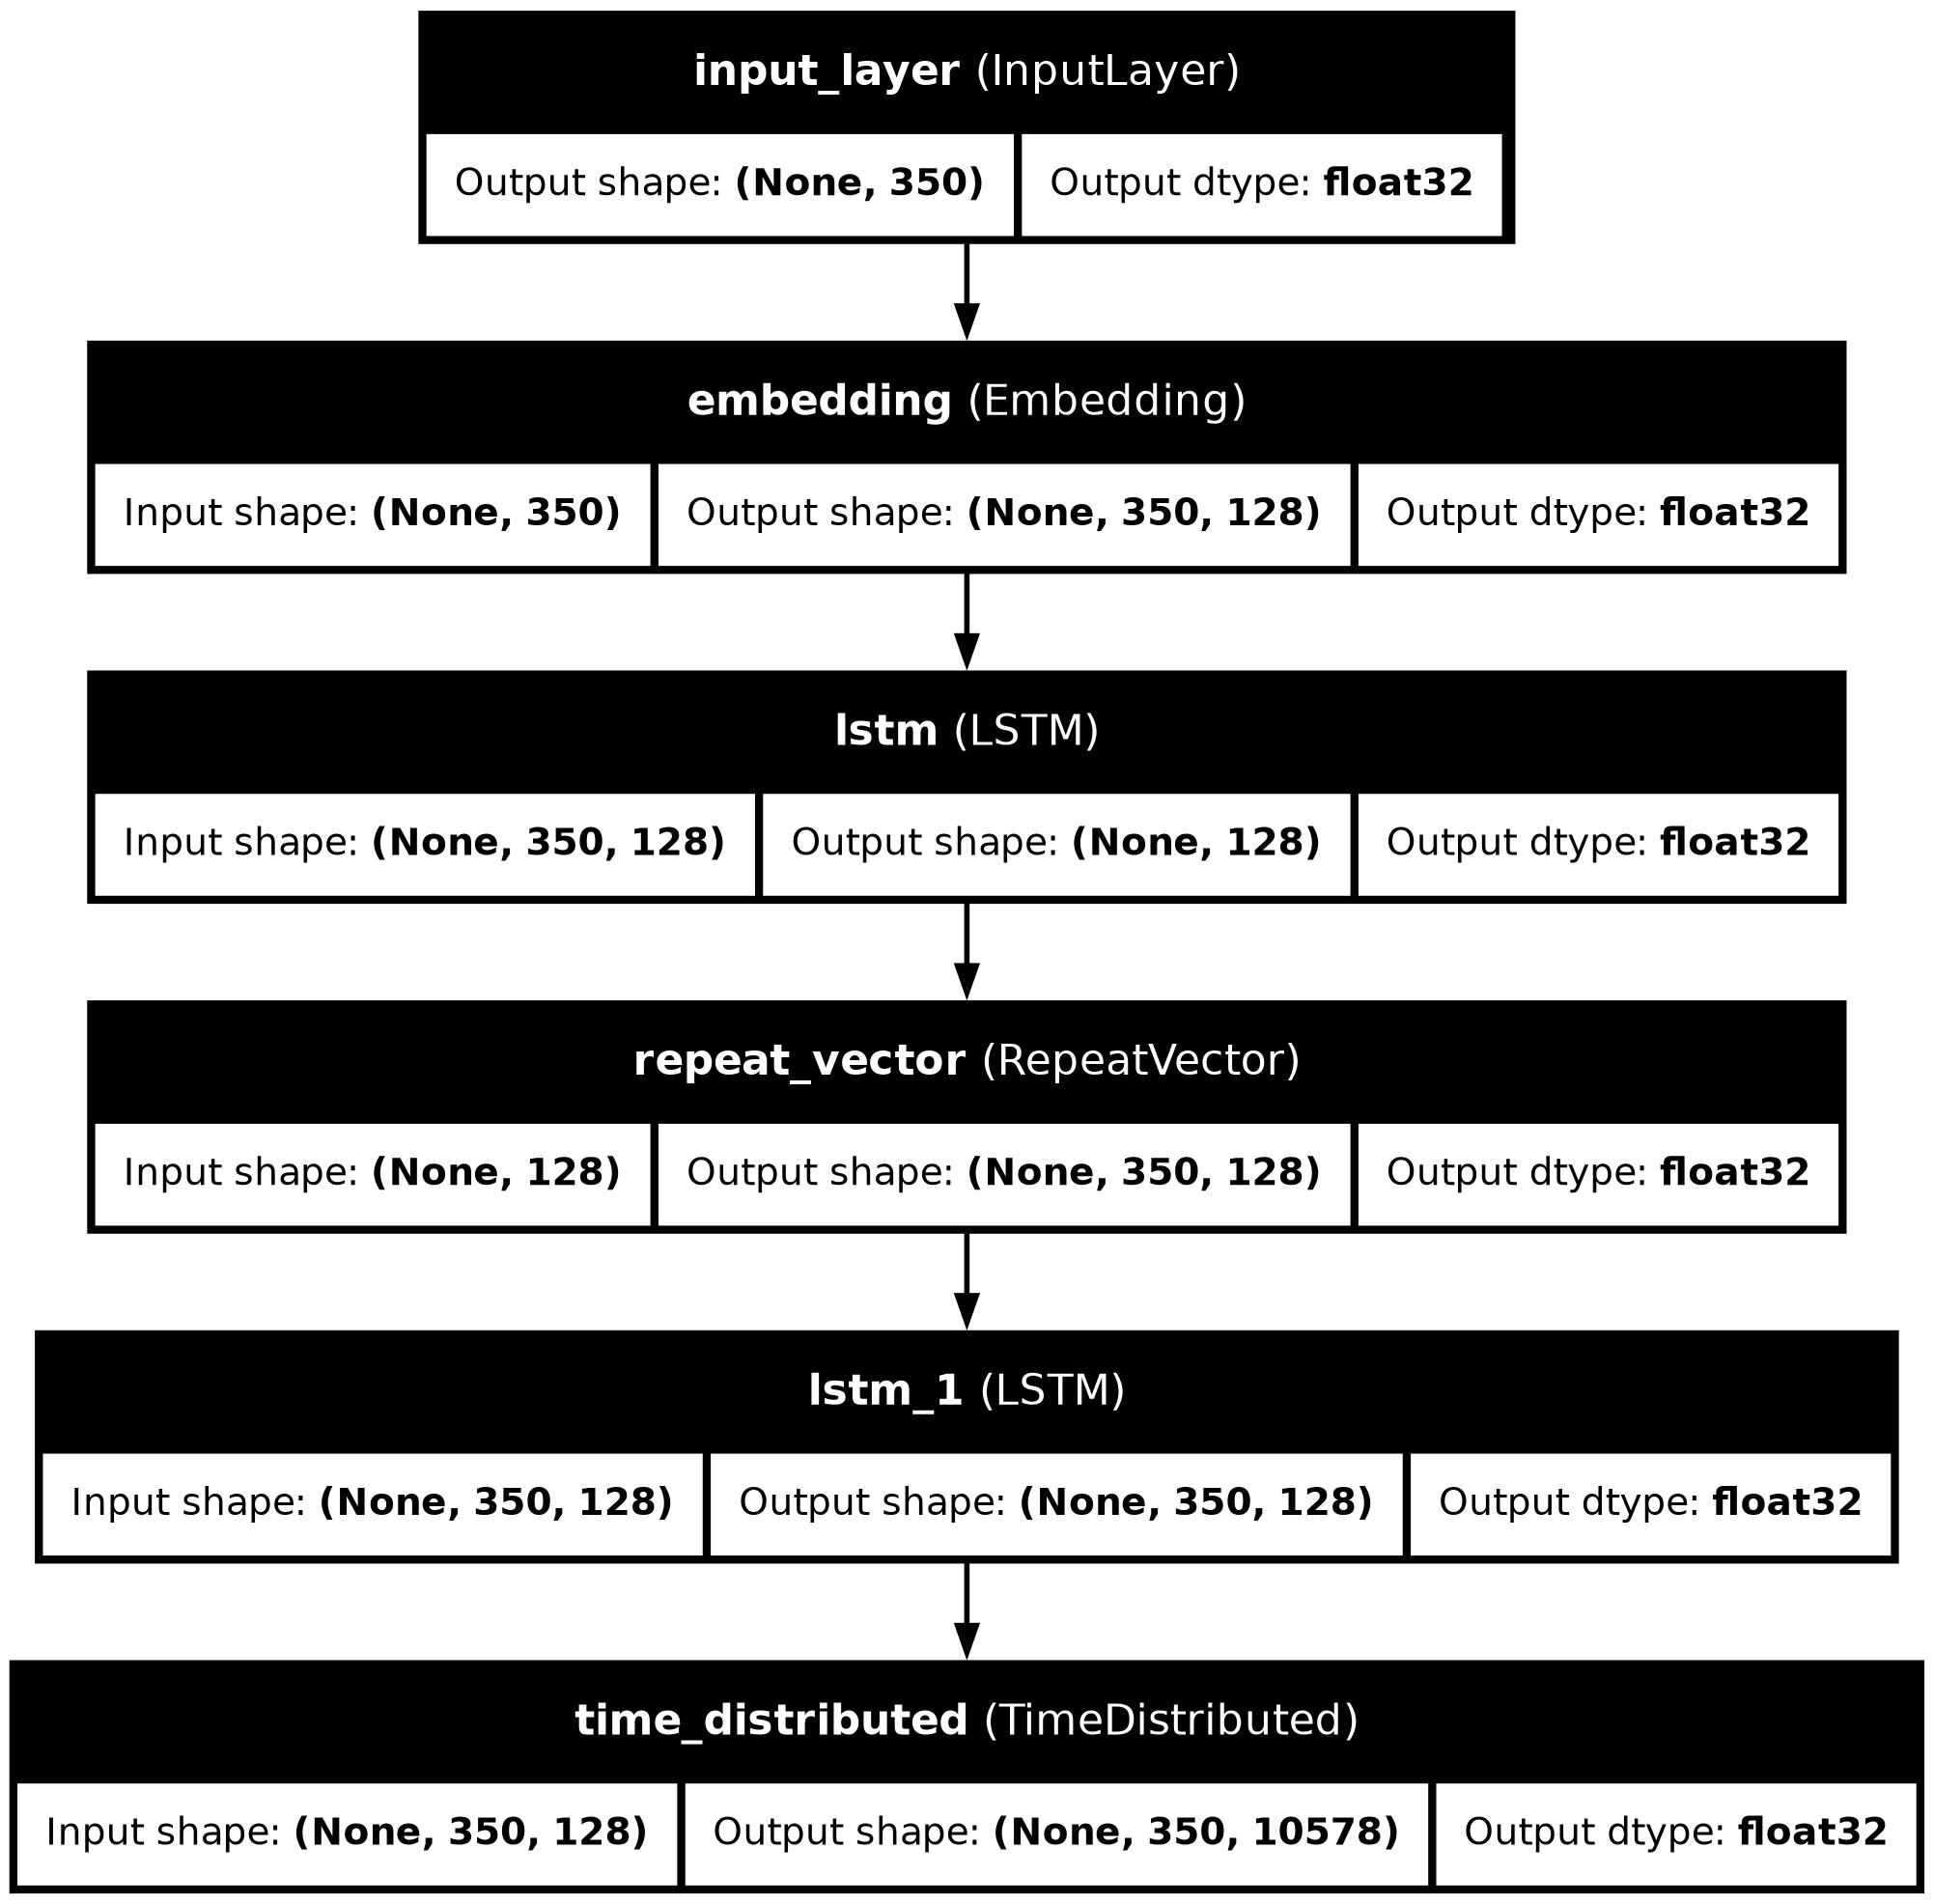

In [16]:
keras.utils.plot_model(autoencoder,show_shapes=True, show_dtype=True, show_layer_names=True)

**<a id="6"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Training the AutoEncoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [17]:
autoencoder.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['acc'])
checkpoint_cb =ModelCheckpoint("model.keras", save_best_only=True)
early_stopping_cb =EarlyStopping(patience=10, restore_best_weights=True)
hist = autoencoder.fit(X_train,y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 126s 311ms/step - acc: 0.8824 - loss: 2.6525 - val_acc: 0.9021 - val_loss: 0.7252
Epoch 2/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 302ms/step - acc: 0.8995 - loss: 0.7456 - val_acc: 0.9031 - val_loss: 0.7184
Epoch 3/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 302ms/step - acc: 0.9000 - loss: 0.7430 - val_acc: 0.9034 - val_loss: 0.7108
Epoch 4/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 302ms/step - acc: 0.9007 - loss: 0.7349 - val_acc: 0.9036 - val_loss: 0.7091
Epoch 5/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 302ms/step - acc: 0.9010 - loss: 0.7327 - val_acc: 0.9038 - val_loss: 0.7053
Epoch 6/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 302ms/step - acc: 0.9013 - loss: 0.7263 - val_acc: 0.9038 - val_loss: 0.7038
Epoch 7/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 303ms/step - acc: 0.9013 - loss: 0.7255 - val_acc: 0.9037 - val_loss: 0.7040
Epoch 8/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 102s 303ms/step - acc: 0.9009 - loss: 0.7294 - val_acc: 0.9038 - val_loss: 0.7033
Epoch 9/50
337/337 ━━━━━

**<a id="7"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Evaluation the AutoEncoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [18]:
hist_=pd.DataFrame(hist.history)
hist_

,acc,loss,val_acc,val_loss
0,0.896803,1.312841,0.902108,0.725206
1,0.899757,0.743407,0.903127,0.718370
2,0.900556,0.737035,0.903380,0.710843
3,0.900956,0.733204,0.903639,0.709141
4,0.901063,0.731025,0.903762,0.705258
5,0.901122,0.729237,0.903762,0.703782
6,0.901113,0.727961,0.903746,0.704039
7,0.901121,0.727221,0.903781,0.703314
8,0.901151,0.726094,0.903893,0.702119
9,0.901173,0.725374,0.903828,0.703690


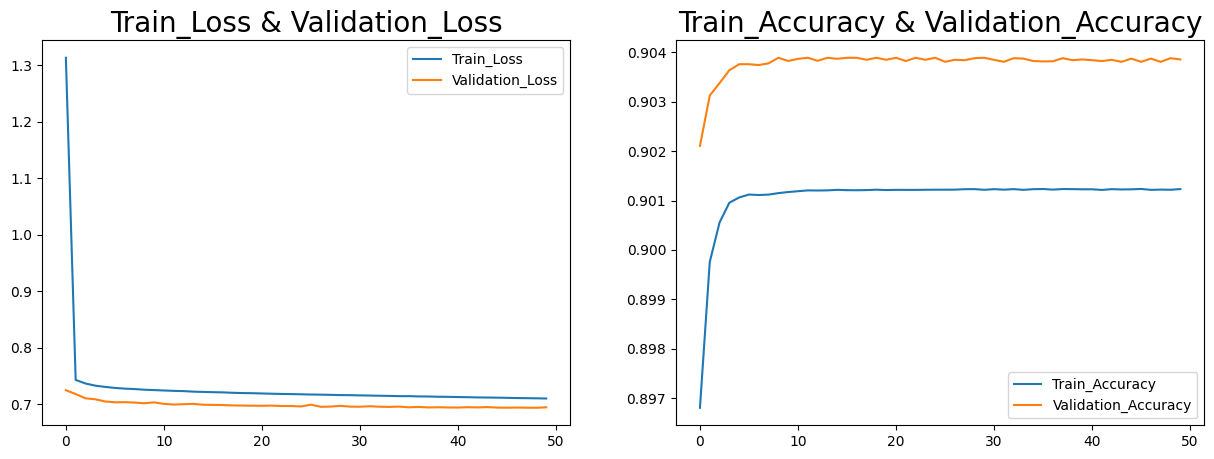

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['acc'],label='Train_Accuracy')
plt.plot(hist_['val_acc'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()
plt.show()

In [20]:
score,acc = autoencoder.evaluate(X_test,y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.9021 - loss: 0.7105
Test Loss = 0.7147389650344849
Test Accuracy = 0.9016703963279724


**<a id="8"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Testing the AutoEncoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [21]:
# Encoder model to encode questions
encoder_model = Model(encoder_inputs, encoder_lstm)

# Decoder model to generate answers
decoder_state_input = Input(shape=(latent_dim,))
decoder_inputs_single = RepeatVector(1)(decoder_state_input)
decoder_lstm_single = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_dense_single = TimeDistributed(Dense(vocab_size, activation='softmax'))

all_outputs = []
inputs = decoder_inputs_single
states = decoder_state_input

for _ in range(max_seq_length):
    outputs, state_h, state_c = decoder_lstm_single(inputs, initial_state=[states, states])
    outputs = decoder_dense_single(outputs)
    all_outputs.append(outputs)
    inputs = outputs
    states = state_h

decoder_model = Model(decoder_state_input, all_outputs)

# Function to generate text
def generate_answer(question):
    if isinstance(question, np.ndarray):
        question = question[0]  # Assuming question is the first element of the array
    seq = tokenizer.texts_to_sequences([question])
    padded_seq = pad_sequences(seq, maxlen=max_seq_length, padding='post')
    state = encoder_model.predict(padded_seq)
    answer_seq = decoder_model.predict(state)

    # Convert answer_seq to list of sequences
    answer_seq = np.argmax(answer_seq, axis=-1)
    # Convert sequences back to textط
    integer_list = [int(arr[0, 0]) for arr in answer_seq]
    answer = tokenizer.sequences_to_texts([integer_list])[0]
    return answer

In [22]:
# Example usage
question = df['Questions'].iloc[100]
print('Question :\n',question)
print('*'*100,'\nAnswer :\n')
print(generate_answer(question)+'.')

Question :
 Are there lifestyle changes that can positively impact cognitive health?
**************************************************************************************************** 
Answer :

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
neuroinflammation  abnormal relievers aquatic flexible inherited aquatic aquatic mosque mosque mosque inherited inherited aquatic aquatic flexible flexible manufacturers inherited inherited overlaps overlaps petroleum flexible flexible flexible petroleum petroleum minimal aquatic you’ve you’ve petroleum flexible flexible flexible flexible flexible aquatic mosque mosque playfulness preoccupied inherited pgrn aquatic aquatic inherited aquatic mosque iowa mosque mosque flexible reaching aquatic flexible platform petroleum petroleum mosque inherited balanced overlaps aquatic mosque mosque flexible flexible aquatic mosque flexible flexible inherited aquatic inherited inherited aquatic inherited inherited aquatic aquatic m